# Super-resolution and 3D reconstruction

In EMCFsys paper fig6, low resolution images were first made super-resolution to High-resolution. And then train segmentation model. At last make 3D reconstruction from 2D-slice segmentation inference.

For the anterior pituitary dataset, the raw low-resolution volume (1024×884×854) was acquired via FIB-SEM. We then performed super-resolution upsampling using EMCellFiner to obtain the high-resolution volume of 4096×3536×854.

For the intestinal epithelial dataset, the raw low-resolution volume (1750×1500×2251) was acquired via FIB-SEM. Similarly, super-resolution upsampling was performed with EMCellFiner, yielding a high-resolution volume of 7000×6000×2251.

Subsequently, we selected 1–4 slice images from each volume to fine-tune the EMCFound model for organelle segmentation on 2D slices. All segmentation outputs can be visualized as 3D structures using Amira or Arivis Pro.

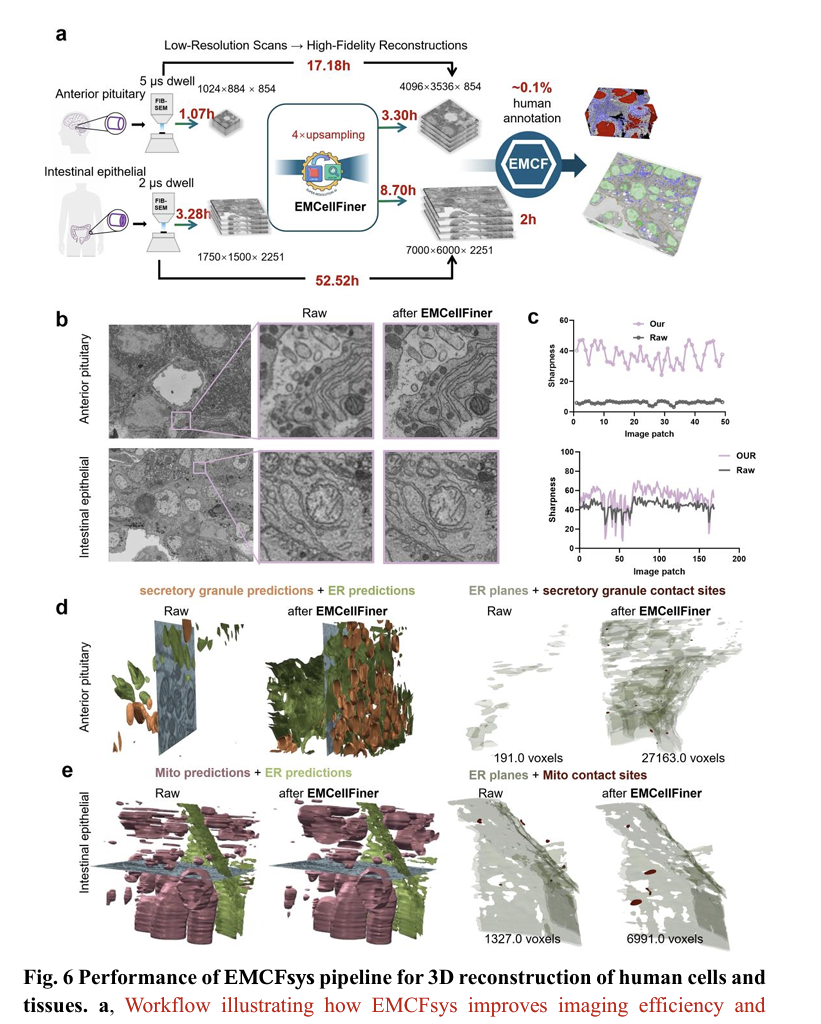

Download the models first

In [ ]:
import os
from huggingface_hub import snapshot_download
from pathlib import Path
BASE_DIR = Path.cwd().resolve().parent

local_model_dir = (BASE_DIR / "models")
snapshot_download(repo_id="Zeyu0102/EMCFsys_models", repo_type="model",
                  local_dir=local_model_dir,
                  local_dir_use_symlinks=False, resume_download=True,
                  max_workers=1)


c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\YZY\miniconda3\envs\EMCF_napari\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

'D:\\napari_EMCF\\EMCFsys\\emcfsys\\models'

Download the data.
The training dataset and the volume data for this demo was stored in Huggingface: Zeyu0102/EMCFsys_3D_vEM.

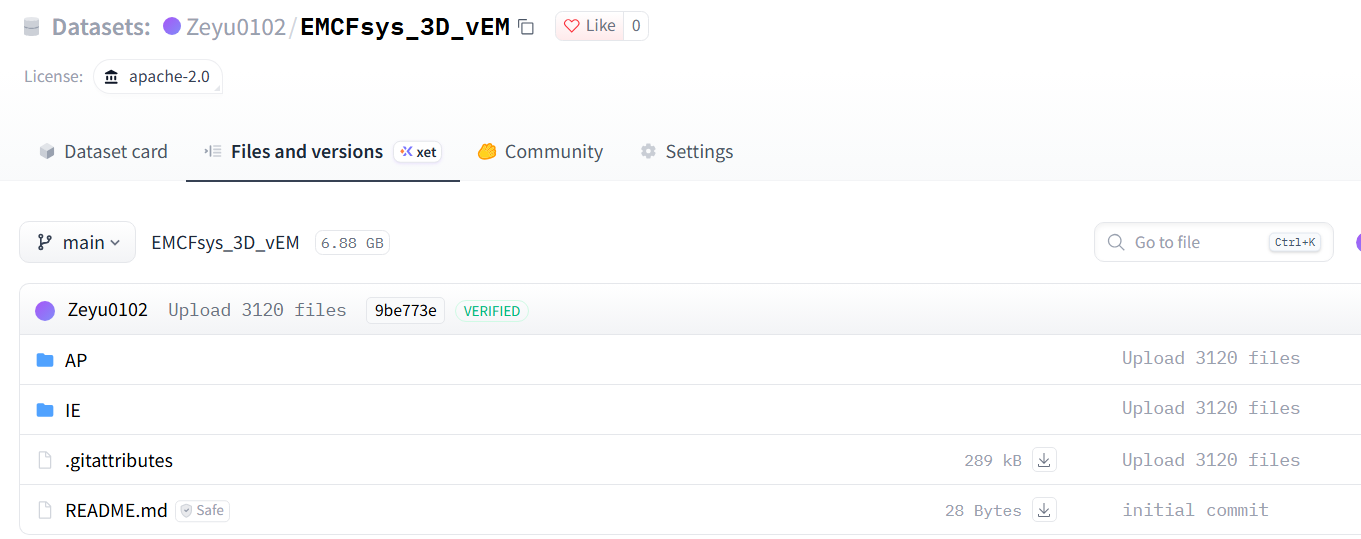

In [ ]:
import os
from huggingface_hub import snapshot_download
from pathlib import Path
BASE_DIR = Path.cwd().resolve()

local_dir = str(BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM")
# save the dataset to local_dir, and set resume_download=True to resume the download if it was interrupted
snapshot_download(repo_id="Zeyu0102/EMCFsys_3D_vEM", repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True)

print("AP and IE volume data downloaded successfully.")

Low resolution vEM data acquization with volume size 1024 * 884 * 854
And we apply SR-Resolution through EMCellFiner, made the size upsampling to 4096 * 3536 * 854

First, we configure the AP Dataset to perform segmentation on four organelles: the nucleus, mitochondria, autophagosomes, and membranes.

This template‑based setup originates from MMLab; the corresponding tutorial is available at [MMSegmentation_Tutorial.ipynb](https://github.com/open-mmlab/mmsegmentation/blob/main/demo/MMSegmentation_Tutorial.ipynb).

In [ ]:
from mmseg.registry import DATASETS
from mmseg.datasets import BaseSegDataset
from pathlib import Path
import sys
@DATASETS.register_module()
class AP_Dataset(BaseSegDataset):
    METAINFO = dict(
        classes = ('background',"ER", "Mitochondria", "LD", "Nucleus"),
        palette = [[0,0,0], 
                   [255, 0, 0], 
                   [0, 255, 0],
                   [0, 0, 255],
                   [255, 255, 0]])

    def __init__(self,
                 img_suffix='.tif',
                 seg_map_suffix='.png',
                 **kwargs) -> None:
        super().__init__(
            img_suffix=img_suffix,
            seg_map_suffix=seg_map_suffix,
            **kwargs)
        



# Locate the repository whether Jupyter starts in the project root or demo/.
BASE_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(BASE_DIR))
print(f"Project root: {BASE_DIR}")

# define dataset root and directory for images and annotations
data_root = (BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP")

# Load the training cfg first
from mmengine import Config
cfg_file = (BASE_DIR / "src" / "thirdParty" / "mmsegmentation" / "configs" / "AP_seg" / "EMCF_UperNet_AP_seg.py")
cfg = Config.fromfile(cfg_file)

Then we modify several configuration parameters following the rules below, including `num_classes`, `data_root`, `train_pipeline`, and other related settings.

In [ ]:
from copy import deepcopy

# Configure the two-class semantic-segmentation task.
cfg.model.decode_head.num_classes = 5
cfg.model.auxiliary_head.num_classes = 5
cfg.dataset_type = "AP_Dataset"

# MMEngine config values must be serializable Python values, not Path objects.
data_root = BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP"
model_path = BASE_DIR / "models" / "MAE_backbone_mmbackend.pth"
work_dir = BASE_DIR / "demo" / "logs" / "AP_3DRescon"
root = str(data_root.resolve())

cfg.data_root = root
cfg.load_from = str(model_path.resolve())
cfg.work_dir = str(work_dir.resolve())
cfg.randomness = dict(seed=0)

crop_size = (512,512)
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations'),
    dict(type='RandomCrop', 
         crop_size = (crop_size[0]*1.5, crop_size[1]*1.5), 
         cat_max_ratio=0.75),
    dict(
        type='RandomResize',
        scale=crop_size,
        ratio_range=(0.5, 2),
        keep_ratio=True,
        clip_object_border=False),
    
    dict(type="RandomCrop", crop_size=crop_size, cat_max_ratio=0.75),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=crop_size),
    dict(type='PhotoMetricDistortion'),
    dict(type='PackSegInputs')
]

# Keep validation images at their original size. EncoderDecoder.test_cfg uses
# mode="slide", crop_size=(512, 512), and stride=(480, 480).
cfg.test_pipeline = [
    dict(type="LoadImageFromFile"),
    dict(type="LoadAnnotations"),
    dict(type="PackSegInputs"),
]

for loader, split, pipeline in (
    (cfg.train_dataloader, "train", cfg.train_pipeline),
    (cfg.val_dataloader, "val", cfg.test_pipeline),
):
    loader.dataset.type = cfg.dataset_type
    loader.dataset.data_root = root
    loader.dataset.data_prefix = dict(img_path="image", seg_map_path="label")
    loader.dataset.pipeline = pipeline
    loader.dataset.ann_file = f"splits/{split}.txt"
    # A dataset class defined in a notebook is safest with no worker processes
    # on Windows, and it also avoids stale registry state after rerunning cells.
    loader.num_workers = 0
    loader.persistent_workers = False

cfg.train_dataloader.batch_size = 2

# This downloaded dataset has no splits/test.txt, so test uses the validation
# split until a dedicated test split is provided.
cfg.test_dataloader = deepcopy(cfg.val_dataloader)
cfg.test_dataloader.dataset.ann_file = "splits/val.txt"
cfg.test_evaluator = deepcopy(cfg.val_evaluator)

print(f"Config:\n{cfg.pretty_text}")


We then start the training.

In [ ]:
from mmengine.runner import Runner

runner = Runner.from_cfg(cfg)
# start training
runner.train()

## Inference from 2D slices image in 3D Volume.

#### First, we need to apply Super-resolution to generate High resolution image from Low resolution image

In [ ]:
import sys
import numpy as np
import os
from PIL import Image
import pathlib
#-----------------------------------------------------
# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = pathlib.Path.cwd().resolve()
# Add the root directory to Python path for package lookup
sys.path.insert(0, str(current_dir.parent))

project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")

print(f"Project root: {project_root}")




# define dataset root and directory for images and annotations
LR_path = (project_root / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP" / "Volume" / "LR")
HR_path = (project_root / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP" / "Volume" / "HR")

# Make HR_path to restore the High-Resolution (HR) image
if not os.path.exists(HR_path):
    os.makedirs(HR_path)
    

from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy
import torch
from PIL import Image
import numpy as np

model = HATModel(scale=4, tile_size=512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for img_name in os.listdir(LR_path)[::100]:
    if img_name.lower().endswith(('.tif')):
        img_path = os.path.join(LR_path, img_name)
        img = Image.open(img_path).convert("RGB")
        img_out = hat_infer_numpy(model, np.array(img), device=device)
        result_path = os.path.join(HR_path, img_name)
        _ = Image.fromarray(img_out).save(result_path)
        print(f"Done: {result_path}")

#### Then we can find High Resolution images in demo\datasets_temp\SR_and_3D_reconstruct\AP\Volume\HR

And Inference the 2D images using the trianed models

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))

from mmengine import Config
from mmseg.apis import init_model, inference_model, fill_holes_for_classes
from configs.register_models.runtime import *


cfg_path = str(BASE_DIR / "demo" / "logs" / "AP_3DRescon" / "EMCF_UperNet_AP_seg.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR / "demo" / "logs" / "AP_3DRescon").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================


# 1. load the config and model
cfg = Config.fromfile(cfg_path)
cfg.test_cfg.crop_size = (512,512)
cfg.test_cfg.stride = (400, 400)
# load the model to GPU, if no cuda, use device="cpu"
model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")
palette = np.array(model.dataset_meta['palette'], dtype=np.uint8)

# 2. inference from folder of images
folder_path = BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP" / "Volume" / "HR" 
result_dir = BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "AP" / "Volume" / "Results" 
result_dir.mkdir(exist_ok=True)

img_ext = (".tif",)
for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(img_ext):
        img_path = str(folder_path / img_file)
        save_path = str(result_dir / img_file)
        print(f"Processing: {img_file}")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Cannot read image {img_file}, skip.")
            continue

        with torch.no_grad():
            result = inference_model(model, img)

        # Extract raw prediction mask
        pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        # ========== postprocess to fill the hole ==========
        pred_mask_filled = fill_holes_for_classes(pred_mask_np, target_classes=[3, 4])

        # -------- get palatte in the label--------
        # palette shape: (num_classes, 3) RGB
        pred_rgb = palette[pred_mask_filled]
        pred_bgr = cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR)

        # save the color segmentation mask
        _ = cv2.imwrite(save_path, pred_bgr)

        # # Optional: visualize the result
        # paste the label to the original image for visualization
        vis_img = cv2.addWeighted(img, 0.5, pred_bgr, 0.5, 0)
        _ = cv2.imwrite(str(result_dir / f"vis_{img_file}"), vis_img)
         
print(f"\n✅ Inference completed for all images in {folder_path}.\nResults saved to {result_dir}")

# Demo2 IE 3D reconstruction

Low resolution (LR) volume 1750 * 1500 * 2250 (xyz), so each slice image is 1750 * 1500.

First, we can make Super Resolution to High Resolution (HR) up to the 7000 * 6000.

### Super Resolution and make low resolution volume to high resolution volume

In [ ]:
import sys
import numpy as np
import os
from PIL import Image
import pathlib
#-----------------------------------------------------
# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = pathlib.Path.cwd().resolve()
# Add the root directory to Python path for package lookup
sys.path.insert(0, str(current_dir.parent))
print(f"Project root: {current_dir}")

# define dataset root and directory for images and annotations
LR_path = (current_dir/ "datasets_temp" / "EMCFsys_3D_vEM" / "IE" / "Volume" / "LR")
HR_path = (current_dir / "datasets_temp" / "EMCFsys_3D_vEM" / "IE" / "Volume" / "HR")

# Make HR_path to restore the High-Resolution (HR) image
if not os.path.exists(HR_path):
    os.makedirs(HR_path)
    

from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy
import torch
from PIL import Image
import numpy as np

model = HATModel(scale=4, tile_size=512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for img_name in os.listdir(LR_path):
    if img_name.lower().endswith(('.tif')):
        img_path = os.path.join(LR_path, img_name)
        img = Image.open(img_path).convert("RGB")
        img_out = hat_infer_numpy(model, np.array(img), device=device)
        result_path = os.path.join(HR_path, img_name)
        _ = Image.fromarray(img_out).convert("L").save(result_path)
        print(f"Done: {result_path}")

Then we select 
NO.0200  and  NO.1328 for train

No.0600 for val

No.02000 for test

And 3D volume with 2250 2D images for 3D reconstruction.

In this demo, we first train a model to segment the cell membrane.

In [ ]:
from copy import deepcopy
from pathlib import Path
import sys
from PIL import Image
from mmseg.registry import DATASETS
from mmseg.datasets import BaseSegDataset
    
@DATASETS.register_module()
class IE_Membrane_Dataset(BaseSegDataset):
    METAINFO = dict(
        classes = ('background',"Membrane"),
        palette = [[0,0,0], 
                   [255, 0, 0]])

    def __init__(self,
                 img_suffix='.tif',
                 seg_map_suffix='.png',
                 **kwargs) -> None:
        super().__init__(
            img_suffix=img_suffix,
            seg_map_suffix=seg_map_suffix,
            **kwargs)
        
# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)

# define dataset root and directory for images and annotations
data_root = (project_root / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "IE")

# Load the training cfg first
from mmengine import Config
cfg_file = (project_root / "src" / "thirdParty" / "mmsegmentation" / "configs" / "IE_seg" / "EMCF_UperNet_IE_seg.py")
cfg = Config.fromfile(cfg_file)
# Configure the two-class semantic-segmentation task.
cfg.model.decode_head.num_classes = 2
cfg.model.auxiliary_head.num_classes = 2
cfg.dataset_type = "IE_Membrane_Dataset"

# MMEngine config values must be serializable Python values, not Path objects.
data_root = project_root / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "IE"
model_path = project_root / "models" / "MAE_backbone_mmbackend.pth"
work_dir = project_root / "demo" / "logs" / "IE_3DRescon"
root = str(data_root.resolve())

cfg.data_root = root
cfg.load_from = str(model_path.resolve())
cfg.work_dir = str(work_dir.resolve())
cfg.randomness = dict(seed=0)
crop_size = (512,512)
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations'),
    dict(type='RandomCrop', crop_size = crop_size, cat_max_ratio=0.75),
    dict(
        type='RandomResize',
        scale=crop_size,
        ratio_range=(0.5, 2),
        keep_ratio=True,
        clip_object_border=False),
    
    dict(type="RandomCrop", crop_size=crop_size, cat_max_ratio=0.75),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=crop_size),
    dict(type='PhotoMetricDistortion'),
    dict(type='PackSegInputs')
]

# Keep validation images at their original size. EncoderDecoder.test_cfg uses
# mode="slide", crop_size=(512, 512), and stride=(480, 480).
cfg.test_pipeline = [
    dict(type="LoadImageFromFile"),
    dict(type="LoadAnnotations"),
    dict(type="PackSegInputs"),
]

for loader, split, pipeline in (
    (cfg.train_dataloader, "train", cfg.train_pipeline),
    (cfg.val_dataloader, "val", cfg.test_pipeline),
):
    loader.dataset.type = cfg.dataset_type
    loader.dataset.data_root = root
    loader.dataset.data_prefix = dict(img_path="image", seg_map_path="label")
    loader.dataset.pipeline = pipeline
    loader.dataset.ann_file = f"splits/{split}.txt"
    # A dataset class defined in a notebook is safest with no worker processes
    # on Windows, and it also avoids stale registry state after rerunning cells.
    loader.num_workers = 0
    loader.persistent_workers = False

cfg.train_dataloader.batch_size = 2

# This downloaded dataset has no splits/test.txt, so test uses the validation
# split until a dedicated test split is provided.
cfg.test_dataloader = deepcopy(cfg.val_dataloader)
cfg.test_dataloader.dataset.ann_file = "splits/val.txt"
cfg.test_evaluator = deepcopy(cfg.val_evaluator)

from mmengine.runner import Runner

runner = Runner.from_cfg(cfg)
# start training
runner.train()

### Then inference from slices

In [ ]:
import pathlib
import sys
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))

from mmengine import Config
from mmseg.apis import init_model, inference_model, fill_holes_for_classes
from configs.register_models.runtime import *


cfg_path = str(BASE_DIR / "demo" / "logs" / "IE_3DRescon" / "EMCF_UperNet_IE_seg.py")
# get the path to the best checkpoint,
# using search to find the best checkpoint in the work_dir
for file in (BASE_DIR / "demo" / "logs" / "IE_3DRescon").glob("best_mIoU_iter_*.pth"):
    ckpt_path = str(file)
    break
# =================================================================


# 1. load the config and model
cfg = Config.fromfile(cfg_path)
cfg.test_cfg.crop_size = (512, 512)
cfg.test_cfg.stride = (400, 400)
# load the model to GPU, if no cuda, use device="cpu"
model = init_model(cfg, ckpt_path, device="cuda:0")
print("✅ Model loaded successfully!")
print(f"Classes info: {model.dataset_meta['classes']}")
palette = np.array(model.dataset_meta['palette'], dtype=np.uint8)

# 2. inference from folder of images
folder_path = BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "IE" / "Volume" / "HR" 
result_dir = BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_3D_vEM" / "IE" / "Volume" / "Results" 
result_dir.mkdir(exist_ok=True)

img_ext = (".tif",)
for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(img_ext):
        img_path = str(folder_path / img_file)
        save_path = str(result_dir / img_file)
        print(f"Processing: {img_file}")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Cannot read image {img_file}, skip.")
            continue

        with torch.no_grad():
            result = inference_model(model, img)

        # Extract raw prediction mask

        pred_mask_np = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        # ========== postprocess to fill the hole ==========
        # pred_mask_filled = fill_holes_for_classes(pred_mask_np, target_classes=[3, 4])

        # -------- get palatte in the label--------
        # palette shape: (num_classes, 3) RGB
        pred_rgb = palette[pred_mask_np]
        pred_bgr = cv2.cvtColor(pred_rgb, cv2.COLOR_RGB2BGR)

        # save the color segmentation mask
        _ = cv2.imwrite(save_path, pred_bgr)

        # # Optional: visualize the result
        # paste the label to the original image for visualization
        vis_img = cv2.addWeighted(img, 0.5, pred_bgr, 0.5, 0)
        _ = cv2.imwrite(str(result_dir / f"vis_{img_file}"), vis_img)
         
print(f"\n✅ Inference completed for all images in {folder_path}.\nResults saved to {result_dir}")